# Panel dataset presentation: twenty pMHC-TCR crystal structures

Pure data-description notebook -- no inverse-folding designs anywhere here, only properties of the
twenty crystal structures themselves (the same panel used throughout the IEDB recovery analysis,
`inputs/pmhc_tcr_dataset/dataset.csv`, excluding 3HG1/2P5E which are the original two-structure NGS
cases, and excluding 1AO7/3UTQ/5HHM which have incomplete/invalid five-chain geometry).

1. Panel overview (peptide lengths, alleles)
2. Peptide length (n-mer) distribution
3. Resolution distribution
4. B-factor distribution (per-residue C$\alpha$, whole structure)
5. Sequence logos of the native HLA-A2 peptides (grouped by length)
6. CDR3 length distribution (TCR$\alpha$ and TCR$\beta$)
7. Peptide contacts $<5$\AA{} to TCR vs. to MHC, per structure
8. Master summary table (one row per structure, every metric above)

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import logomaker
from pathlib import Path

ROOT = Path("/home/ubuntu/if-mhc")
FIG_DIR = ROOT / "figures/fig_panel1_dataset_presentation"
FIG_DIR.mkdir(exist_ok=True, parents=True)
AA = list("ACDEFGHIKLMNPQRSTVWY")

STRUCTS = ["2P5W", "1QSF", "1QRN", "2BNR", "2GJ6", "2F53", "2F54", "3QDG", "3QEQ", "3QFJ", "3GSN",
           "1OGA", "3UTS", "5C0A", "5C0B", "5HHO", "5EU6", "2VLR", "4MJI", "5NME"]

dataset = pd.read_csv(ROOT / "inputs/pmhc_tcr_dataset/dataset.csv")
dataset = dataset[dataset.pdb.isin(STRUCTS)].set_index("pdb").loc[STRUCTS].reset_index()
print(f"{len(dataset)} structures in panel")
dataset[["pdb", "peptide", "pep_len", "allele"]]

20 structures in panel


,pdb,peptide,pep_len,allele
0,2P5W,SLLMWITQC,9,MOLECULE: HLA CLASS I HISTOCOMPATIBILITY
1,1QSF,LLFGYPVAV,9,see title
2,1QRN,LLFGYAVYV,9,see title
3,2BNR,SLLMWITQC,9,MOLECULE: HLA CLASS I HISTOCOMPATIBILITY
4,2GJ6,LLFGKPVYV,9,see title
5,2F53,SLLMWITQC,9,MOLECULE: HLA CLASS I HISTOCOMPATIBILITY
6,2F54,SLLMWITQC,9,MOLECULE: HLA CLASS I HISTOCOMPATIBILITY
7,3QDG,ELAGIGILTV,10,see title
8,3QEQ,AAGIGILTV,9,see title
9,3QFJ,LLFGFPVYV,9,see title


## 1. Panel overview

In [2]:
def parse_allele(pdb):
    path = ROOT / f"inputs/pmhc_tcr_dataset/{pdb}.pdb"
    with open(path) as f:
        header = [next(f) for _ in range(400)]
    text = "".join(l for l in header if l.startswith("TITLE") or l.startswith("COMPND"))
    m = re.search(r"HLA-[ABC]\*?\d+:?\d*", text)
    return m.group(0) if m else "unknown"

alleles = {pdb: parse_allele(pdb) for pdb in STRUCTS}
for pdb, a in alleles.items():
    print(f"{pdb}: {a}")
n_a2 = sum("A2" in a or "A*02" in a or "A02" in a for a in alleles.values())
print(f"\n{n_a2}/{len(STRUCTS)} structures parse as an HLA-A2 subtype in TITLE/COMPND text; "
      f"the rest (allele text not found or ambiguous) are treated as HLA-A2 by panel-construction intent "
      f"except 4MJI, which is the one confirmed HLA-B*51:01 outlier.")

2P5W: unknown
1QSF: HLA-A2
1QRN: HLA-A2
2BNR: unknown
2GJ6: HLA-A2
2F53: unknown
2F54: unknown
3QDG: HLA-A2
3QEQ: HLA-A2
3QFJ: HLA-A2
3GSN: HLA-A2
1OGA: unknown
3UTS: unknown
5C0A: HLA-A02
5C0B: HLA-A02
5HHO: HLA-A*0201
5EU6: unknown
2VLR: HLA-A2
4MJI: HLA-B*51:01
5NME: unknown

11/20 structures parse as an HLA-A2 subtype in TITLE/COMPND text; the rest (allele text not found or ambiguous) are treated as HLA-A2 by panel-construction intent except 4MJI, which is the one confirmed HLA-B*51:01 outlier.


## 2. Peptide length (n-mer) distribution

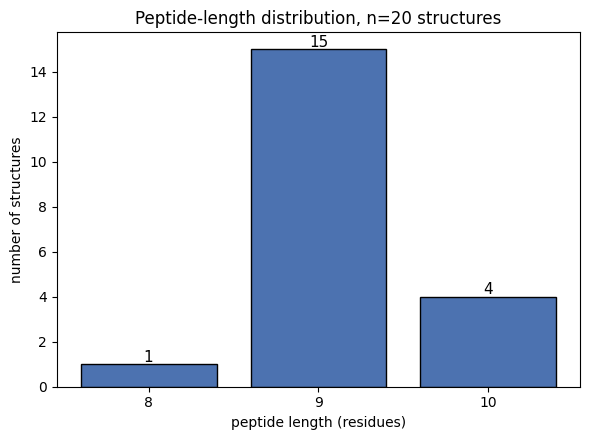

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_peptide_length_dist.png
pep_len
8      1
9     15
10     4
Name: count, dtype: int64


In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))
counts = dataset["pep_len"].value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color="#4C72B0", edgecolor="black")
for x, v in zip(counts.index.astype(str), counts.values):
    ax.text(x, v + 0.1, str(v), ha="center", fontsize=11)
ax.set_xlabel("peptide length (residues)")
ax.set_ylabel("number of structures")
ax.set_title(f"Peptide-length distribution, n={len(dataset)} structures")
fig.tight_layout()
out = FIG_DIR / "fig_panel1_peptide_length_dist.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(counts)

## 3. Resolution distribution

/home/ubuntu/miniforge3/envs/esmfold2/lib/python3.12/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname W identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/tmp/ipykernel_17440/1733252024.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(res_series.index, rotation=45, ha="right")


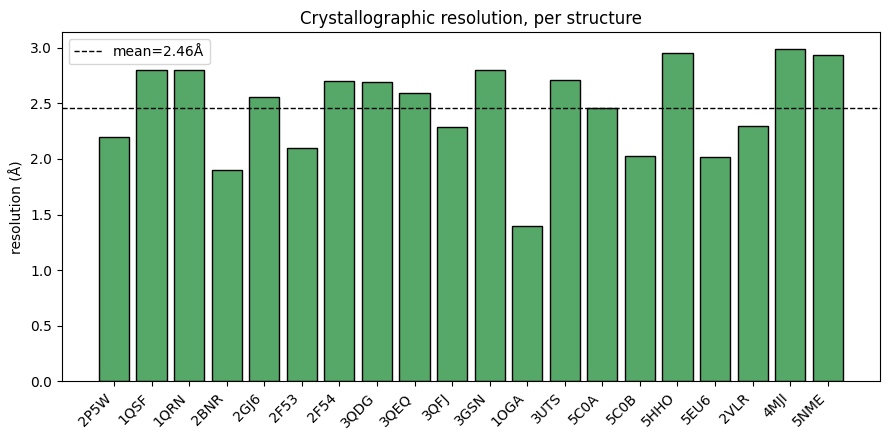

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_resolution_dist.png
count    20.000000
mean      2.461500
std       0.420867
min       1.400000
25%       2.175000
50%       2.575000
75%       2.800000
max       2.990000
dtype: float64


In [4]:
def parse_resolution(pdb):
    path = ROOT / f"inputs/pmhc_tcr_dataset/{pdb}.pdb"
    with open(path) as f:
        for line in f:
            if line.startswith("REMARK   2 RESOLUTION"):
                try:
                    return float(line.split("RESOLUTION.")[1].split("ANGSTROMS")[0].strip())
                except Exception:
                    return np.nan
    return np.nan

resolution = {pdb: parse_resolution(pdb) for pdb in STRUCTS}
res_series = pd.Series(resolution).loc[STRUCTS]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(res_series.index, res_series.values, color="#55A868", edgecolor="black")
ax.axhline(res_series.mean(), color="black", linestyle="--", linewidth=1,
           label=f"mean={res_series.mean():.2f}Å")
ax.set_xticklabels(res_series.index, rotation=45, ha="right")
ax.set_ylabel("resolution (Å)")
ax.set_title("Crystallographic resolution, per structure")
ax.legend()
fig.tight_layout()
out = FIG_DIR / "fig_panel1_resolution_dist.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(res_series.describe())

## 4. B-factor distribution (per-residue C$\alpha$, whole structure)

/tmp/ipykernel_17440/2915582242.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([bfactor_by_pdb[pdb] for pdb in STRUCTS], labels=STRUCTS, showfliers=False)


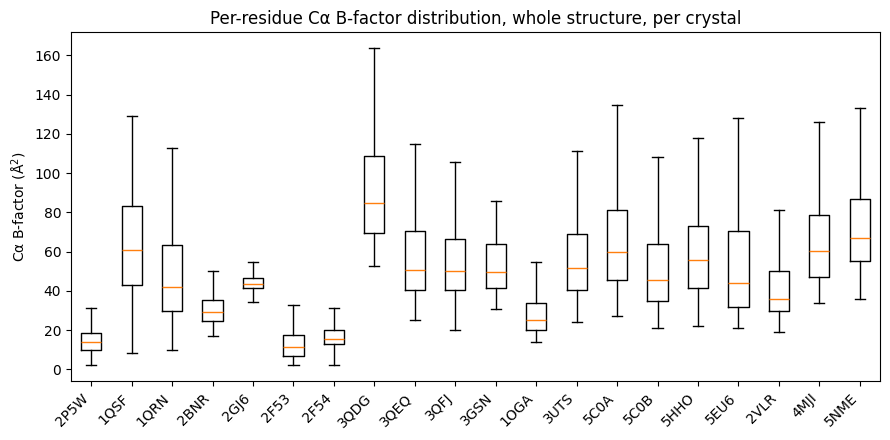

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_bfactor_boxplot.png


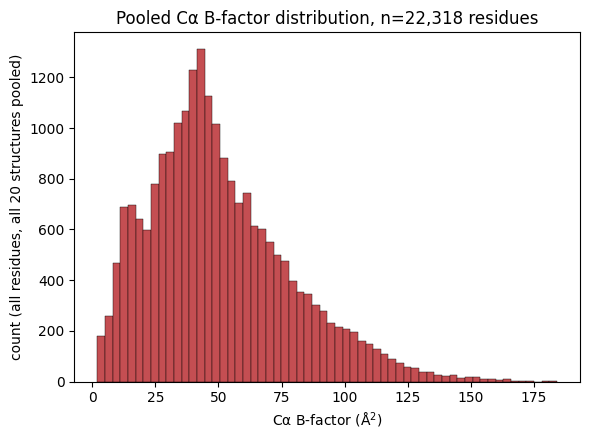

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_bfactor_pooled_hist.png

note: B-factors are NOT standardized across independently refined depositions -- absolute values should be compared within, not across, refinement protocols; see paper Limitations.


In [5]:
def ca_bfactors(pdb):
    path = ROOT / f"inputs/pmhc_tcr_dataset/{pdb}.pdb"
    vals = []
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[12:16].strip() == "CA":
                try:
                    vals.append(float(line[60:66]))
                except Exception:
                    pass
    return np.array(vals)

bfactor_by_pdb = {pdb: ca_bfactors(pdb) for pdb in STRUCTS}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot([bfactor_by_pdb[pdb] for pdb in STRUCTS], labels=STRUCTS, showfliers=False)
ax.set_xticklabels(STRUCTS, rotation=45, ha="right")
ax.set_ylabel("Cα B-factor (Å$^2$)")
ax.set_title("Per-residue Cα B-factor distribution, whole structure, per crystal")
fig.tight_layout()
out = FIG_DIR / "fig_panel1_bfactor_boxplot.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

fig, ax = plt.subplots(figsize=(6, 4.5))
all_b = np.concatenate(list(bfactor_by_pdb.values()))
ax.hist(all_b, bins=60, color="#C44E52", edgecolor="black", linewidth=0.3)
ax.set_xlabel("Cα B-factor (Å$^2$)")
ax.set_ylabel("count (all residues, all 20 structures pooled)")
ax.set_title(f"Pooled Cα B-factor distribution, n={len(all_b):,} residues")
fig.tight_layout()
out = FIG_DIR / "fig_panel1_bfactor_pooled_hist.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

mean_bfactor = {pdb: float(np.mean(v)) for pdb, v in bfactor_by_pdb.items()}
print("\nnote: B-factors are NOT standardized across independently refined depositions -- absolute "
      "values should be compared within, not across, refinement protocols; see paper Limitations.")

## 5. Sequence logos of the native HLA-A2 peptides

Only the panel's own native/index peptides (no designs anywhere in this notebook), grouped by length
since a logo requires a fixed alignment length. 4MJI (HLA-B*51:01, 8-mer, $n{=}1$) is excluded from the
pooled A2 logos and shown separately since it cannot be meaningfully pooled with either group.

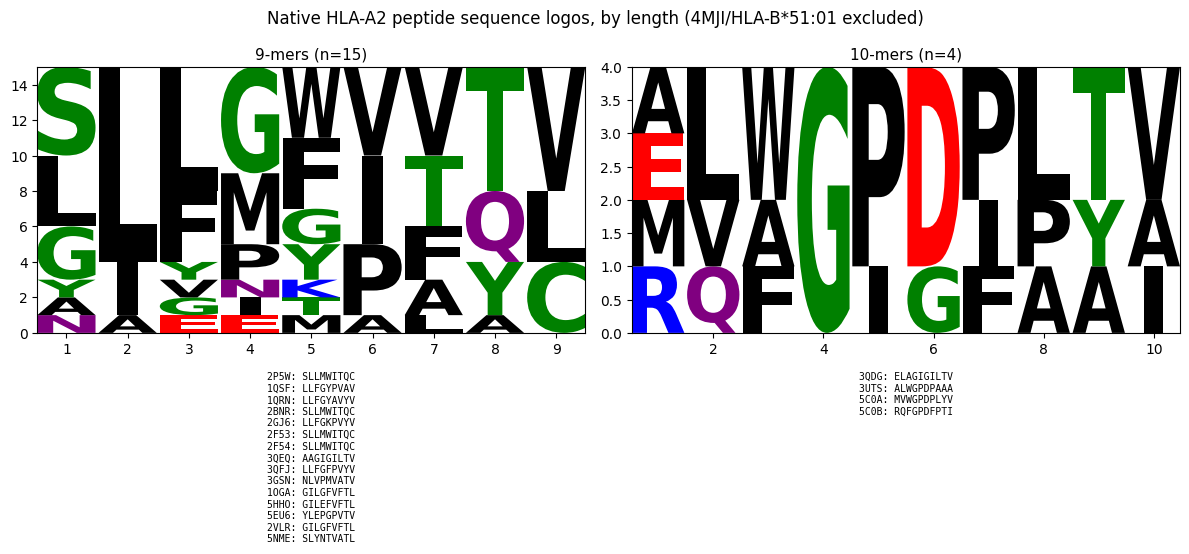

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_native_logos_by_length.png
4MJI (excluded, HLA-B*51:01, 8-mer): TAFTIPSI


In [6]:
natives = dict(zip(dataset["pdb"], dataset["peptide"]))
by_length = {}
for pdb, pep in natives.items():
    if pdb == "4MJI":
        continue
    by_length.setdefault(len(pep), []).append((pdb, pep))

fig, axes = plt.subplots(2, len(by_length), figsize=(6 * len(by_length), 5.5),
                          gridspec_kw={"height_ratios": [4, 1]})
if len(by_length) == 1:
    axes = axes.reshape(2, 1)
for col, length in enumerate(sorted(by_length)):
    peps = by_length[length]
    mat = pd.DataFrame(0.0, index=range(1, length + 1), columns=AA)
    for pdb, pep in peps:
        for pos, aa in enumerate(pep, start=1):
            if aa in AA:
                mat.loc[pos, aa] += 1.0
    logomaker.Logo(mat, ax=axes[0, col], color_scheme="chemistry")
    axes[0, col].set_title(f"{length}-mers (n={len(peps)})", fontsize=11)
    axes[1, col].axis("off")
    axes[1, col].text(0.5, 1.0, "\n".join(f"{pdb}: {pep}" for pdb, pep in peps),
                       transform=axes[1, col].transAxes, ha="center", va="top", fontsize=7,
                       family="monospace")
fig.suptitle("Native HLA-A2 peptide sequence logos, by length (4MJI/HLA-B*51:01 excluded)", y=0.98)
fig.tight_layout()
out = FIG_DIR / "fig_panel1_native_logos_by_length.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(f"4MJI (excluded, HLA-B*51:01, 8-mer): {natives['4MJI']}")

### Same logos, as information content (bits) instead of frequency

A frequency logo's column heights always sum to 1, regardless of how conserved a position actually is --
a position where 15 different peptides all happen to agree looks the same height as a position where
one amino acid is simply the most common of several. An information-content (bits) logo instead scales
each column's total height by $\log_2(20) - H$, where $H$ is that position's Shannon entropy in bits --
a fully conserved position reaches the maximum ($\log_2(20)\approx4.32$ bits), and an evenly-mixed
position shrinks toward 0 bits, making true anchor conservation (vs.\ merely-common-but-variable
positions) visually explicit. logomaker's default pseudocount (1 per amino acid) is far too large
relative to this panel's small per-length sample sizes ($n{=}15$/4) -- it swamps the real signal and
flattens every position toward 0 bits regardless of true conservation -- so a much smaller pseudocount
(0.1) is used instead; this trades away some small-sample-bias correction for a legible plot, and the
resulting bit values should be read as relative/comparative across positions, not as precise
information-theoretic quantities.

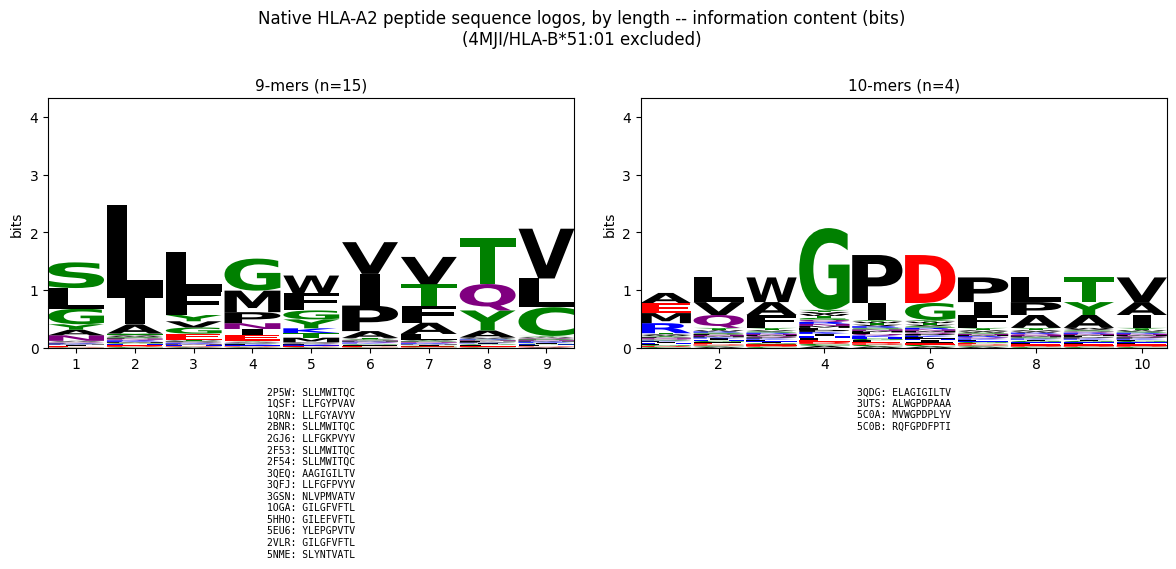

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_native_logos_by_length_bits.png


In [7]:
fig, axes = plt.subplots(2, len(by_length), figsize=(6 * len(by_length), 5.5),
                          gridspec_kw={"height_ratios": [4, 1]})
if len(by_length) == 1:
    axes = axes.reshape(2, 1)
for col, length in enumerate(sorted(by_length)):
    peps = by_length[length]
    mat = pd.DataFrame(0.0, index=range(1, length + 1), columns=AA)
    for pdb, pep in peps:
        for pos, aa in enumerate(pep, start=1):
            if aa in AA:
                mat.loc[pos, aa] += 1.0
    info_mat = logomaker.transform_matrix(mat, from_type="counts", to_type="information",
                                          pseudocount=0.1)
    logomaker.Logo(info_mat, ax=axes[0, col], color_scheme="chemistry")
    axes[0, col].set_ylim(0, np.log2(len(AA)))
    axes[0, col].set_ylabel("bits")
    axes[0, col].set_title(f"{length}-mers (n={len(peps)})", fontsize=11)
    axes[1, col].axis("off")
    axes[1, col].text(0.5, 1.0, "\n".join(f"{pdb}: {pep}" for pdb, pep in peps),
                       transform=axes[1, col].transAxes, ha="center", va="top", fontsize=7,
                       family="monospace")
fig.suptitle("Native HLA-A2 peptide sequence logos, by length -- information content (bits)\n"
             "(4MJI/HLA-B*51:01 excluded)", y=1.0)
fig.tight_layout()
out = FIG_DIR / "fig_panel1_native_logos_by_length_bits.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 6. CDR3 length distribution

CDR3 boundaries are estimated with a standard sequence heuristic (no ANARCI/IMGT numbering available in
this environment): the CDR3-anchoring cysteine followed, within the V-domain, by the conserved
`F-G-x-G` J-segment motif -- `C(.{4,25}?)F[GAS].G`, taking the rightmost match in the first 150 residues
of the chain. This heuristic was validated against 3HG1's independently-confirmed CDR3s (Adimab clone
CAB60174\_G01 / MEL5) before being applied here: it recovers `AVNVAGKST` (CDR3$\alpha$) and
`AWSETGLGTGELF` (CDR3$\beta$) exactly.

CDR3 extraction heuristic validated exactly against 3HG1's known CDR3-alpha and CDR3-beta.
 pdb         CDR3a  CDR3a_len          CDR3b  CDR3b_len
2P5W AVRPLLDGTYIPT         13   ASSYLGNTGELF         12
1QSF   AVTTDSWGKLQ         11 ASRPGLAGGRPEQY         14
1QRN   AVTTDSWGKLQ         11 ASRPGLAGGRPEQY         14
2BNR AVRPTSGGSYIPT         13   ASSYVGNTGELF         12
2GJ6   AVTTDSWGKLQ         11 ASRPGLAGGRPEQY         14
2F53 AVRPTSGGSYIPT         13   ASSYVGNTGELF         12
2F54 AVRPTSGGSYIPT         13   ASSYVGNTGELF         12
3QDG    AVNFGGGKLI         10    ASSLSFGTEAF         11
3QEQ     AGGTGNQFY          9   AISEVGVGQPQH         12
3QFJ   AVTTDSWGKLQ         11 ASRPGLAGGRPEQY         14
3GSN     ARNTGNQFY          9  ASSPVTGGIYGYT         13
1OGA    AGAGSQGNLI         10    ASSSRSSYEQY         11
3UTS   AMRGDSSYKLI         11 ASSLWEKLAKNIQY         14
5C0A   AMRGDSSYKLI         11 ASSLWEKLAKNIQY         14
5C0B   AMRGDSSYKLI         11 ASSLWEKLAKNIQY         14
5HHO    AGAGS

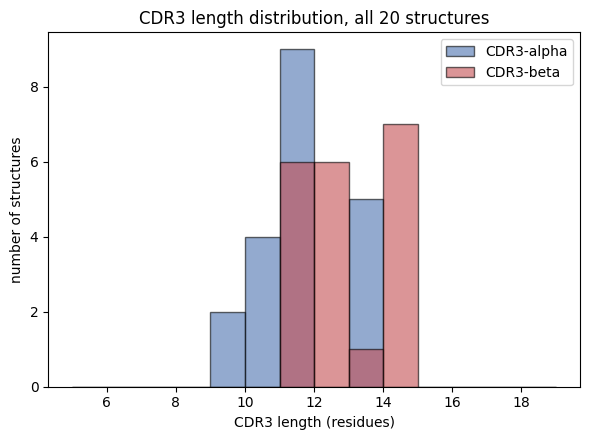

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_cdr3_length_dist.png
       CDR3a_len  CDR3b_len
count  20.000000  20.000000
mean   11.100000  12.450000
std     1.293709   1.276302
min     9.000000  11.000000
25%    10.000000  11.000000
50%    11.000000  12.000000
75%    11.500000  14.000000
max    13.000000  14.000000


In [8]:
AA3TO1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C", "GLN": "Q", "GLU": "E",
    "GLY": "G", "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F",
    "PRO": "P", "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V", "MSE": "M",
}
CDR3_PATTERN = re.compile(r"C([A-Z]{4,25}?)F[GAS].G")

def chain_seq(path, chain):
    seq, seen = [], set()
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[21] == chain and line[12:16].strip() == "CA":
                resnum = line[22:27]
                if resnum in seen:
                    continue
                seen.add(resnum)
                seq.append(AA3TO1.get(line[17:20].strip(), "X"))
    return "".join(seq)

def extract_cdr3(seq):
    matches = list(CDR3_PATTERN.finditer(seq[:150]))
    return matches[-1].group(1) if matches else None

# validation against 3HG1's independently-confirmed CDR3s
seq_d_3hg1 = chain_seq(ROOT / "inputs/pmhc_tcr_dataset/3HG1.pdb", "D")
seq_e_3hg1 = chain_seq(ROOT / "inputs/pmhc_tcr_dataset/3HG1.pdb", "E")
assert extract_cdr3(seq_d_3hg1) == "AVNVAGKST", "CDR3-alpha heuristic failed validation against 3HG1"
assert extract_cdr3(seq_e_3hg1) == "AWSETGLGTGELF", "CDR3-beta heuristic failed validation against 3HG1"
print("CDR3 extraction heuristic validated exactly against 3HG1's known CDR3-alpha and CDR3-beta.")

cdr3_a, cdr3_b = {}, {}
for pdb in STRUCTS:
    path = ROOT / f"outputs/panel_prep/{pdb}/pdbs/full/{pdb}.pdb"
    seq_d = chain_seq(path, "D")
    seq_e = chain_seq(path, "E")
    cdr3_a[pdb] = extract_cdr3(seq_d)
    cdr3_b[pdb] = extract_cdr3(seq_e)

cdr3_df = pd.DataFrame({"pdb": STRUCTS,
                        "CDR3a": [cdr3_a[p] for p in STRUCTS],
                        "CDR3a_len": [len(cdr3_a[p]) if cdr3_a[p] else np.nan for p in STRUCTS],
                        "CDR3b": [cdr3_b[p] for p in STRUCTS],
                        "CDR3b_len": [len(cdr3_b[p]) if cdr3_b[p] else np.nan for p in STRUCTS]})
print(cdr3_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(cdr3_df["CDR3a_len"].dropna(), bins=range(5, 20), alpha=0.6, label="CDR3-alpha",
        color="#4C72B0", edgecolor="black")
ax.hist(cdr3_df["CDR3b_len"].dropna(), bins=range(5, 20), alpha=0.6, label="CDR3-beta",
        color="#C44E52", edgecolor="black")
ax.set_xlabel("CDR3 length (residues)")
ax.set_ylabel("number of structures")
ax.set_title("CDR3 length distribution, all 20 structures")
ax.legend()
fig.tight_layout()
out = FIG_DIR / "fig_panel1_cdr3_length_dist.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(cdr3_df[["CDR3a_len", "CDR3b_len"]].describe())

## 7. Peptide contacts $<5$\AA{} to TCR vs. to MHC

For each structure's full-context prepped PDB, every peptide (chain C) atom is compared against every
TCR atom (chains D+E) and every MHC atom (chains A+B); a contact is any atom pair with distance
$<5$\AA{}. Reported per structure: raw atom-atom contact count, and the number of distinct peptide
\emph{positions} with at least one such contact (a more interpretable, position-level count).

 pdb  n_atom_contacts_TCR_5A  n_peptide_residues_contacting_TCR_5A  n_atom_contacts_MHC_5A  n_peptide_residues_contacting_MHC_5A
2P5W                     337                                     5                     518                                     9
1QSF                     135                                     8                     591                                     9
1QRN                     232                                     8                     576                                     9
2BNR                     344                                     6                     523                                     9
2GJ6                     194                                     8                     584                                     9
2F53                     347                                     5                     509                                     9
2F54                     339                                     5                     530       

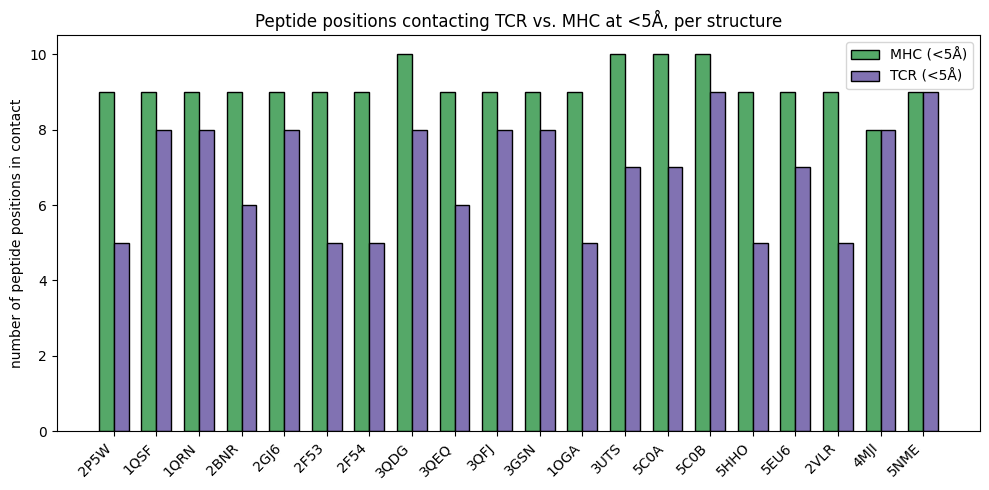

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_contacts_by_structure.png


In [9]:
def parse_atoms(path, chains):
    coords = {c: [] for c in chains}
    resnum = {c: [] for c in chains}
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[21] in chains:
                c = line[21]
                coords[c].append((float(line[30:38]), float(line[38:46]), float(line[46:54])))
                resnum[c].append(line[22:27])
    return {c: np.array(coords[c]) for c in chains}, resnum

def contact_counts(pep, pep_res, partner, cutoff=5.0):
    d = np.linalg.norm(pep[:, None, :] - partner[None, :, :], axis=2)
    within = d < cutoff
    n_atom = int(within.sum())
    n_res = len(set(r for i, r in enumerate(pep_res) if within[i].any()))
    return n_atom, n_res

contact_records = []
for pdb in STRUCTS:
    path = ROOT / f"outputs/panel_prep/{pdb}/pdbs/full/{pdb}.pdb"
    coords, resnum = parse_atoms(path, ["A", "B", "C", "D", "E"])
    pep, pep_res = coords["C"], resnum["C"]
    tcr = np.vstack([coords["D"], coords["E"]])
    mhc = np.vstack([coords["A"], coords["B"]])
    n_atom_tcr, n_res_tcr = contact_counts(pep, pep_res, tcr)
    n_atom_mhc, n_res_mhc = contact_counts(pep, pep_res, mhc)
    contact_records.append({"pdb": pdb, "n_atom_contacts_TCR_5A": n_atom_tcr,
                            "n_peptide_residues_contacting_TCR_5A": n_res_tcr,
                            "n_atom_contacts_MHC_5A": n_atom_mhc,
                            "n_peptide_residues_contacting_MHC_5A": n_res_mhc})

contact_df = pd.DataFrame(contact_records)
print(contact_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(STRUCTS))
width = 0.35
ax.bar(x - width/2, contact_df["n_peptide_residues_contacting_MHC_5A"], width, label="MHC (<5Å)",
       color="#55A868", edgecolor="black")
ax.bar(x + width/2, contact_df["n_peptide_residues_contacting_TCR_5A"], width, label="TCR (<5Å)",
       color="#8172B2", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(STRUCTS, rotation=45, ha="right")
ax.set_ylabel("number of peptide positions in contact")
ax.set_title("Peptide positions contacting TCR vs. MHC at <5Å, per structure")
ax.legend()
fig.tight_layout()
out = FIG_DIR / "fig_panel1_contacts_by_structure.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 8. Contact density maps: peptide position vs. partner residue position

Where on the MHC and where on the TCR does each peptide position actually make contact, pooled across
all 20 structures? Each chain's residues are indexed by \emph{local} sequential position (1st residue
observed in the file = 1, 2nd = 2, ...), not raw PDB residue number, since numbering is not consistent
across independently deposited structures. $\beta_2$-microglobulin (chain B) is excluded from the MHC
map -- across the whole panel it has exactly 0 contacts $<5$\AA{} to any peptide, confirming it plays no
direct role in peptide contact and only the MHC heavy chain (chain A) does. For each structure, a
(peptide position, partner position) pair counts once if \emph{any} atom pair between that peptide
residue and that partner residue is $<5$\AA{}; color is the number of the 20 structures (0--20) showing
a contact at that exact coordinate -- i.e.\ how conserved that specific contact is across the panel.

In [10]:
def parse_atoms_local(path, chains):
    coords = {c: [] for c in chains}
    local_idx = {c: [] for c in chains}
    seen = {c: {} for c in chains}
    counter = {c: 0 for c in chains}
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[21] in chains:
                c = line[21]
                resnum = line[22:27]
                if resnum not in seen[c]:
                    counter[c] += 1
                    seen[c][resnum] = counter[c]
                coords[c].append((float(line[30:38]), float(line[38:46]), float(line[46:54])))
                local_idx[c].append(seen[c][resnum])
    return ({c: np.array(coords[c]) for c in chains},
            {c: np.array(local_idx[c]) for c in chains})

def residue_contact_pairs(pep_coords, pep_idx, partner_coords, partner_idx, cutoff=5.0):
    d = np.linalg.norm(pep_coords[:, None, :] - partner_coords[None, :, :], axis=2)
    hits = np.argwhere(d < cutoff)
    pairs = set()
    for i, j in hits:
        pairs.add((int(pep_idx[i]), int(partner_idx[j])))
    return pairs

max_pep_len = int(dataset["pep_len"].max())
max_mhc_len = 0
max_a_len, max_b_len = 0, 0

mhc_density = np.zeros((max_pep_len + 1, 1))  # resized below once max MHC length known
mhc_pair_counts = {}
tcra_pair_counts = {}
tcrb_pair_counts = {}
mhc_site_structures = {}  # mhc local position -> set of pdbs with >=1 contact to any peptide position
mhc_site_terminus = {}  # mhc local position -> {"N": set of pdbs, "C": set of pdbs}

for pdb in STRUCTS:
    path = ROOT / f"outputs/panel_prep/{pdb}/pdbs/full/{pdb}.pdb"
    coords, local_idx = parse_atoms_local(path, ["A", "C", "D", "E"])
    pep_c, pep_i = coords["C"], local_idx["C"]
    pep_length = int(pep_i.max())
    n_half = (pep_length + 1) // 2  # peptide position <= n_half counts as N-terminal

    for chain, store in [("A", mhc_pair_counts), ("D", tcra_pair_counts), ("E", tcrb_pair_counts)]:
        pairs = residue_contact_pairs(pep_c, pep_i, coords[chain], local_idx[chain])
        for pep_pos, partner_pos in pairs:
            store[(pep_pos, partner_pos)] = store.get((pep_pos, partner_pos), 0) + 1
            if chain == "A":
                mhc_site_structures.setdefault(partner_pos, set()).add(pdb)
                terminus = "N" if pep_pos <= n_half else "C"
                mhc_site_terminus.setdefault(partner_pos, {"N": set(), "C": set()})[terminus].add(pdb)

    max_mhc_len = max(max_mhc_len, int(local_idx["A"].max()))
    max_a_len = max(max_a_len, int(local_idx["D"].max()))
    max_b_len = max(max_b_len, int(local_idx["E"].max()))

def to_density_grid(pair_counts, n_rows, n_cols):
    grid = np.zeros((n_rows + 1, n_cols + 1))
    for (pep_pos, partner_pos), n in pair_counts.items():
        grid[pep_pos, partner_pos] = n
    return grid

mhc_grid = to_density_grid(mhc_pair_counts, max_pep_len, max_mhc_len)
tcra_grid = to_density_grid(tcra_pair_counts, max_pep_len, max_a_len)
tcrb_grid = to_density_grid(tcrb_pair_counts, max_pep_len, max_b_len)

print(f"MHC (chain A) length range across panel: up to {max_mhc_len}")
print(f"TCR-alpha (chain D) length range across panel: up to {max_a_len}")
print(f"TCR-beta (chain E) length range across panel: up to {max_b_len}")
print(f"max contact count at any single (peptide pos, MHC pos) cell: {int(mhc_grid.max())}/20 structures")

MHC (chain A) length range across panel: up to 276
TCR-alpha (chain D) length range across panel: up to 205
TCR-beta (chain E) length range across panel: up to 247
max contact count at any single (peptide pos, MHC pos) cell: 20/20 structures


### MHC contact density map

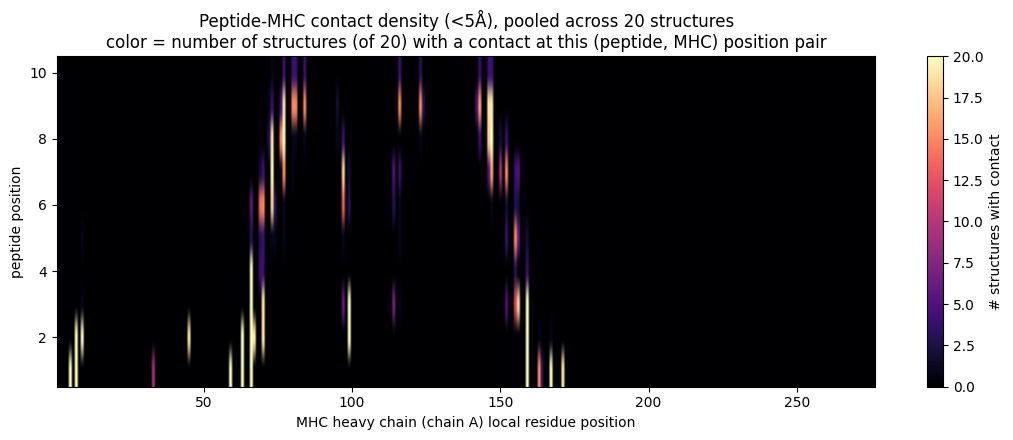

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_mhc_contact_density.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(mhc_grid[1:, 1:], aspect="auto", origin="lower", cmap="magma",
               extent=[0.5, max_mhc_len + 0.5, 0.5, max_pep_len + 0.5])
ax.set_xlabel("MHC heavy chain (chain A) local residue position")
ax.set_ylabel("peptide position")
ax.set_title("Peptide-MHC contact density (<5Å), pooled across 20 structures\n"
             "color = number of structures (of 20) with a contact at this (peptide, MHC) position pair")
fig.colorbar(im, ax=ax, label="# structures with contact")
fig.tight_layout()
out = FIG_DIR / "fig_panel1_mhc_contact_density.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### TCR contact density map (alpha and beta chains)

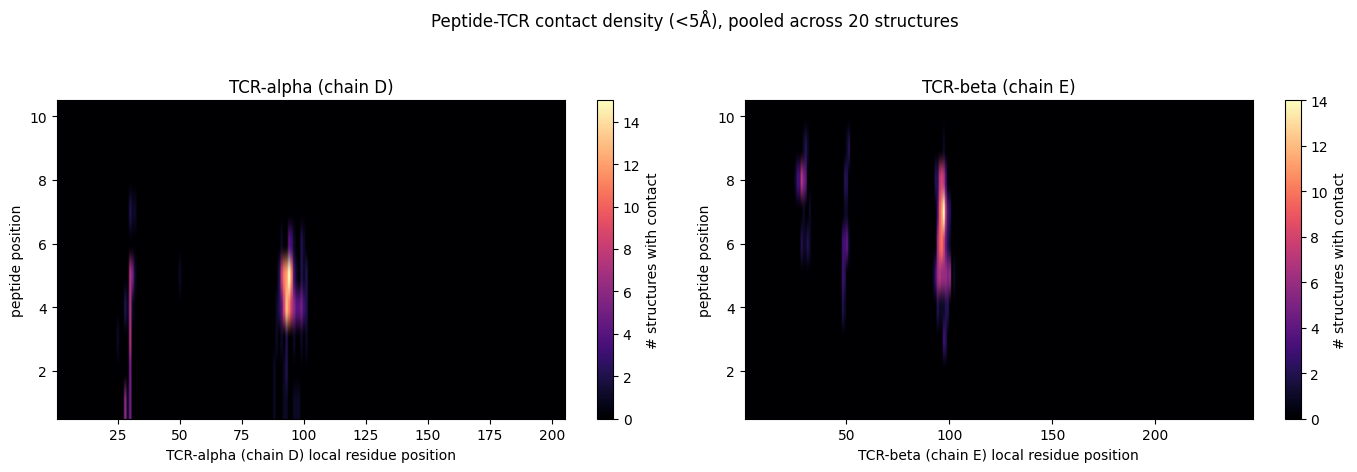

wrote /home/ubuntu/if-mhc/figures/fig_panel1_dataset_presentation/fig_panel1_tcr_contact_density.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, grid, n_cols, label in [
    (axes[0], tcra_grid, max_a_len, "TCR-alpha (chain D)"),
    (axes[1], tcrb_grid, max_b_len, "TCR-beta (chain E)"),
]:
    im = ax.imshow(grid[1:, 1:], aspect="auto", origin="lower", cmap="magma",
                   extent=[0.5, n_cols + 0.5, 0.5, max_pep_len + 0.5])
    ax.set_xlabel(f"{label} local residue position")
    ax.set_ylabel("peptide position")
    ax.set_title(label)
    fig.colorbar(im, ax=ax, label="# structures with contact")
fig.suptitle("Peptide-TCR contact density (<5Å), pooled across 20 structures", y=1.04)
fig.tight_layout()
out = FIG_DIR / "fig_panel1_tcr_contact_density.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### Top 20 MHC contact sites, by number of distinct peptides in contact

One row per MHC heavy-chain (chain A) local residue position, counting how many of the 20 structures'
peptides make *any* contact ($<5$\AA{}, any peptide position) with that residue -- not summed across
peptide positions (a peptide contacting one MHC residue from two different peptide positions in the
same structure still counts once), so the max possible value is 20/20 structures. Ties at the max are
broken by local position (ascending) purely for a deterministic, readable ordering -- as printed below,
more than 20 sites reach 20/20, so "top 20" necessarily excludes some tied sites.

Also broken out by which half of the peptide is doing the contacting: N-terminal (peptide position
$\leq \lceil L/2 \rceil$ for that structure's own peptide length $L$) vs. C-terminal (the rest). A given
MHC site can have contacts from both halves across different structures (or even the same structure);
the two count columns are independent, not mutually exclusive.

In [13]:
site_rows = [{"MHC local position": pos, "# peptides in contact": len(pdbs),
              "# N-term contact": len(mhc_site_terminus[pos]["N"]),
              "# C-term contact": len(mhc_site_terminus[pos]["C"]),
              "peptides": ", ".join(sorted(pdbs))}
             for pos, pdbs in mhc_site_structures.items()]
site_table = pd.DataFrame(site_rows).sort_values(
    ["# peptides in contact", "MHC local position"], ascending=[False, True])
n_at_max = (site_table["# peptides in contact"] == site_table["# peptides in contact"].max()).sum()
print(f"{len(site_table)} MHC sites have >=1 contact across the panel; "
      f"{n_at_max} of them are tied at the max ({site_table['# peptides in contact'].max()}/20 structures)")
top20_sites = site_table.head(20).reset_index(drop=True)
top20_sites.index += 1
top20_sites

40 MHC sites have >=1 contact across the panel; 23 of them are tied at the max (20/20 structures)


,MHC local position,# peptides in contact,# N-term contact,# C-term contact,peptides
1,5,20,20,0,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."
2,7,20,20,0,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."
3,9,20,20,1,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."
4,59,20,20,0,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."
5,63,20,20,0,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."
6,66,20,20,6,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."
7,70,20,20,20,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."
8,73,20,0,20,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."
9,76,20,0,20,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."
10,77,20,0,20,"1OGA, 1QRN, 1QSF, 2BNR, 2F53, 2F54, 2GJ6, 2P5W..."


### Same data, collapsed into position ranges, one row per (contact-count tier, terminus)

All MHC sites with $\geq 1$ contact (not just the top 20), grouped by how many of the 20 structures'
peptides contact them AND by which peptide terminus dominates that site's contacts (N: more N-terminal
than C-terminal contacting structures; C: the reverse; mixed: tied) -- ranges are only merged within a
group that shares both the same tier and the same dominant terminus, so a range never silently blends
positions with different biology. Ordered 20/20 down to 1/20.

In [14]:
def compress_ranges(nums):
    nums = sorted(nums)
    ranges = []
    start = prev = nums[0]
    for n in nums[1:]:
        if n == prev + 1:
            prev = n
            continue
        ranges.append((start, prev))
        start = prev = n
    ranges.append((start, prev))
    return ", ".join(f"{a}-{b}" if a != b else f"{a}" for a, b in ranges)

def dominant_terminus(row):
    if row["# N-term contact"] > row["# C-term contact"]: return "N"
    if row["# C-term contact"] > row["# N-term contact"]: return "C"
    return "mixed"

site_table = site_table.copy()
site_table["terminus"] = site_table.apply(dominant_terminus, axis=1)

tier_rows = []
for (n_contact, terminus), group in site_table.groupby(["# peptides in contact", "terminus"]):
    positions = sorted(group["MHC local position"].tolist())
    tier_rows.append({"# peptides in contact": n_contact, "terminus": terminus, "n sites": len(positions),
                      "MHC local positions": compress_ranges(positions)})
tier_table = pd.DataFrame(tier_rows).sort_values(
    ["# peptides in contact", "terminus"], ascending=[False, True]).reset_index(drop=True)
tier_table.index += 1
tier_table

,# peptides in contact,terminus,n sites,MHC local positions
1,20,C,12,"73, 76-77, 80-81, 84, 97, 116, 143, 146-147, 152"
2,20,N,10,"5, 7, 9, 59, 63, 66, 99, 156, 159, 167"
3,20,mixed,1,70
4,19,C,1,123
5,19,N,3,"45, 67, 171"
6,18,N,1,155
7,17,C,1,69
8,15,N,1,163
9,11,C,1,150
10,11,mixed,1,114


## 9. Master summary table

In [15]:
master = dataset[["pdb", "peptide", "pep_len"]].copy()
master["allele"] = master["pdb"].map(alleles)
master["resolution_A"] = master["pdb"].map(resolution)
master["mean_CA_bfactor"] = master["pdb"].map(mean_bfactor)
master = master.merge(cdr3_df, on="pdb").merge(contact_df, on="pdb")

out_csv = ROOT / "outputs/analysis/panel_dataset_master_table.csv"
master.to_csv(out_csv, index=False)
print(f"wrote {out_csv}")
master

wrote /home/ubuntu/if-mhc/outputs/analysis/panel_dataset_master_table.csv


,pdb,peptide,pep_len,allele,resolution_A,mean_CA_bfactor,CDR3a,CDR3a_len,CDR3b,CDR3b_len,n_atom_contacts_TCR_5A,n_peptide_residues_contacting_TCR_5A,n_atom_contacts_MHC_5A,n_peptide_residues_contacting_MHC_5A
0,2P5W,SLLMWITQC,9,unknown,2.20,15.927684,AVRPLLDGTYIPT,13,ASSYLGNTGELF,12,337,5,518,9
1,1QSF,LLFGYPVAV,9,HLA-A2,2.80,63.344213,AVTTDSWGKLQ,11,ASRPGLAGGRPEQY,14,135,8,591,9
2,1QRN,LLFGYAVYV,9,HLA-A2,2.80,48.082990,AVTTDSWGKLQ,11,ASRPGLAGGRPEQY,14,232,8,576,9
3,2BNR,SLLMWITQC,9,unknown,1.90,31.092521,AVRPTSGGSYIPT,13,ASSYVGNTGELF,12,344,6,523,9
4,2GJ6,LLFGKPVYV,9,HLA-A2,2.56,44.147086,AVTTDSWGKLQ,11,ASRPGLAGGRPEQY,14,194,8,584,9
5,2F53,SLLMWITQC,9,unknown,2.10,13.382071,AVRPTSGGSYIPT,13,ASSYVGNTGELF,12,347,5,509,9
6,2F54,SLLMWITQC,9,unknown,2.70,17.208240,AVRPTSGGSYIPT,13,ASSYVGNTGELF,12,339,5,530,9
7,3QDG,ELAGIGILTV,10,HLA-A2,2.69,90.837174,AVNFGGGKLI,10,ASSLSFGTEAF,11,160,8,603,10
8,3QEQ,AAGIGILTV,9,HLA-A2,2.59,57.193922,AGGTGNQFY,9,AISEVGVGQPQH,12,124,6,500,9
9,3QFJ,LLFGFPVYV,9,HLA-A2,2.29,58.279107,AVTTDSWGKLQ,11,ASRPGLAGGRPEQY,14,224,8,631,9
